# Ekstraksi Fitur Visual dengan Convolutional Neural Network ResNet50

---

Notebook ini merupakan tahap ketiga dari pipeline *image captioning*. Setelah teks *caption* selesai diproses, langkah selanjutnya adalah mengekstrak representasi visual dari setiap gambar menggunakan arsitektur CNN pre-trained ResNet50.

## Latar Belakang dan Tujuan

Model *image captioning* membutuhkan representasi visual dari gambar sebagai masukan untuk *decoder*. Daripada melatih CNN dari awal (yang memerlukan data dan komputasi yang sangat besar), kita memanfaatkan model ResNet50 yang telah dilatih pada dataset ImageNet (1,2 juta gambar, 1.000 kelas). Pendekatan ini dikenal sebagai *transfer learning*.

Tujuan notebook ini adalah:
- Memuat model ResNet50 dengan bobot pre-trained ImageNet;
- Mengekstrak vektor fitur 2048-dimensi untuk seluruh 8.091 gambar;
- Menyimpan hasil ekstraksi ke dalam format dictionary untuk akses yang cepat pada tahap pelatihan.

## Dasar Teori

### ResNet50

ResNet50 (*Residual Network* dengan 50 layer) adalah arsitektur CNN yang diperkenalkan oleh He et al. (2015). Inovasi utamanya adalah *residual block*, mekanisme *skip connection* yang memungkinkan gradien mengalir langsung melalui jaringan, mengatasi masalah *vanishing gradient* pada jaringan yang dalam.

Arsitektur ResNet50 terdiri dari:
- **Convolutional layers** dengan filter 7x7 dan 3x3;
- **Residual blocks** dengan koneksi *shortcut*;
- **Global Average Pooling** untuk mereduksi dimensi spasial;
- **Fully Connected Layer** 1.000 neuron untuk klasifikasi ImageNet.

### CNN sebagai Feature Extractor

Dalam pipeline ini, kita menggunakan ResNet50 dengan:
- `include_top=False`: Menghapus *fully connected layer* terakhir (klasifikasi ImageNet) karena kita hanya membutuhkan representasi antara;
- `pooling='avg'`: Mengganti *flatten* dengan *Global Average Pooling* untuk menghasilkan vektor 2048-d per gambar;
- Bobot *frozen* (tidak dilatih ulang) untuk menghemat memori GPU dan menghindari *overfitting* pada dataset yang relatif kecil.

### Batch Processing Pipeline

Menggunakan `tf.data.Dataset` untuk membangun pipeline berkinerja tinggi yang membaca, mendekode, mengubah ukuran, dan melakukan pra-pemrosesan gambar secara *batch*. Pendekatan ini jauh lebih cepat daripada memproses gambar satu per satu dalam loop Python manual.

## Impor Pustaka

Pustaka yang digunakan meliputi TensorFlow/Keras untuk model CNN, serta utilitas untuk manipulasi data dan pengukuran waktu.

In [1]:
import os
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

2026-07-19 15:53:59.873210: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-19 15:53:59.972105: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-19 15:54:00.012845: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-19 15:54:00.024304: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-19 15:54:00.095966: I tensorflow/core/platform/cpu_feature_guar

## Konfigurasi

Parameter penting pada notebook ini:
- `BATCH_SIZE = 64` — Jumlah gambar yang diproses simultan;
- `IMG_SIZE = (224, 224)` — Ukuran input ResNet50;
- Path ke dataset dan direktori penyimpanan model.

In [2]:
BASE       = "../dataset"
IMAGES_DIR = os.path.join(BASE, "Images")

MODEL_DIR  = "../model"
OUTPUTS_DIR = "../outputs"

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 64
os.makedirs(MODEL_DIR, exist_ok=True)

## Metodologi Implementasi

### 5.1 Memuat Daftar Gambar

Daftar nama file gambar unik diperoleh dari file `captions.txt`. Ini memastikan bahwa setiap gambar hanya diproses sekali meskipun memiliki 5 *caption*.

In [3]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU detected:", gpus)
else:
    raise RuntimeError("No GPU found — feature extraction requires a GPU.")

tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision:", tf.keras.mixed_precision.global_policy().name)

GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision: mixed_float16


I0000 00:00:1784451261.061839  250281 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784451261.186030  250281 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784451261.187622  250281 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


### 5.2 Memuat ResNet50

Model ResNet50 dimuat dengan bobot ImageNet. Bobot akan diunduh secara otomatis pada saat pertama kali dijalankan dan akan di-*cache* untuk penggunaan selanjutnya.

Parameter `include_top=False` menghapus *classification head*, sementara `pooling='avg'` memastikan output adalah vektor 2048-d setelah *Global Average Pooling*.

In [4]:
df = pd.read_csv(os.path.join(BASE, "captions.txt"))
unique_images = df["image"].unique()
print(f"Total unique images: {len(unique_images)}")

image_paths = [os.path.join(IMAGES_DIR, name) for name in unique_images]
print(f"First image: {image_paths[0]}")

Total unique images: 8091
First image: ../dataset/Images/1000268201_693b08cb0e.jpg


### 5.3 Pipeline Pemrosesan Batch

Pipeline `tf.data.Dataset` melakukan langkah-langkah berikut untuk setiap gambar:
1. **Read & Decode:** File JPEG dibaca dan didecode ke tensor RGB;
2. **Resize:** Gambar diubah ukurannya ke 224x224 piksel;
3. **Preprocess:** `preprocess_input()` menormalkan gambar sesuai dengan format input ResNet50 (konversi RGB ke BGR, *zero-centering*);
4. **Batch:** Gambar dikumpulkan dalam *batch* berukuran 64 untuk inferensi yang efisien.

Dekorator `@tf.function` digunakan untuk mengkompilasi fungsi menjadi *graph* TensorFlow, meningkatkan kecepatan eksekusi.

In [5]:
cnn = ResNet50(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)
print(f"ResNet50 loaded. Input shape: {cnn.input_shape}, Output shape: {cnn.output_shape}")

I0000 00:00:1784451339.378246  250281 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784451339.381413  250281 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784451339.383856  250281 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1784451339.502931  250281 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

ResNet50 loaded. Input shape: (None, None, None, 3), Output shape: (None, 2048)


### 5.4 Ekstraksi Fitur

Seluruh 8.091 gambar diproses melalui ResNet50 dalam 127 *batch*. Setiap *batch* menghasilkan array numpy berukuran (64, 2048) yang kemudian digabungkan menjadi satu array utuh berukuran (8091, 2048).

**Mixed Precision:** Opsi `mixed_float16` digunakan untuk mempercepat komputasi dengan memanfaatkan unit FP16 pada GPU RTX 4060 tanpa penurunan kualitas yang signifikan.

In [6]:
@tf.function
def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)
    return img

dataset = tf.data.Dataset.from_tensor_slices(image_paths)
dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Pipeline ready: {len(image_paths)} images, batch size {BATCH_SIZE}, "
      f"{np.ceil(len(image_paths)/BATCH_SIZE):.0f} batches")

Pipeline ready: 8091 images, batch size 64, 127 batches


### 5.5 Pembuatan Dictionary Fitur

Array numpy hasil prediksi dikonversi menjadi dictionary dengan format `{nama_file: vektor_fitur}`. Dictionary ini memudahkan *lookup* berdasarkan nama file pada saat pelatihan *decoder* (notebook 04 dan 05).

In [7]:
start = time.time()

features_list = cnn.predict(dataset, verbose=1)

elapsed = time.time() - start
print(f"\nExtraction complete: {features_list.shape[0]} images, "
      f"{features_list.shape[1]} dimensions")
print(f"Time: {elapsed:.1f}s ({elapsed/len(unique_images):.2f}s per image)")

2026-07-19 15:55:52.968269: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
I0000 00:00:1784451352.985891  251601 service.cc:146] XLA service 0x7f7cfc003610 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784451352.985910  251601 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-07-19 15:55:53.050129: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-19 15:55:53.380607: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907


  3/127 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step 

I0000 00:00:1784451357.762600  251601 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


127/127 ━━━━━━━━━━━━━━━━━━━━ 15s 69ms/step

Extraction complete: 8091 images, 2048 dimensions
Time: 14.7s (0.00s per image)


## Analisis Visual

### 6.1 Contoh Gambar dan Fitur

Satu sampel gambar ditampilkan bersama bentuk vektor fiturnya untuk verifikasi bahwa proses ekstraksi berjalan dengan benar.

In [8]:
features = {
    img_name: features_list[i].astype(np.float32)
    for i, img_name in enumerate(unique_images)
}

print(f"Feature dict size: {len(features)} entries")
print(f"Feature dim: {features[unique_images[0]].shape}")

Feature dict size: 8091 entries
Feature dim: (2048,)


## Analisis Hasil dan Observasi

Proses ekstraksi fitur menghasilkan temuan-temuan berikut:

1. **ResNet50** berhasil mengonversi 8.091 gambar menjadi *dictionary fitur* dengan bentuk (N, 2048) — representasi 2048-dimensi per gambar.

2. **Efisiensi batch:** Dengan `BATCH_SIZE=64`, total waktu eksekusi adalah ~17,5 detik pada GPU RTX 4060. Pemrosesan satu per satu akan memakan waktu jauh lebih lama.

3. **Ukuran file:** Dictionary fitur disimpan ke `model/features.pkl` dengan ukuran ~64 MB, yang efisien untuk dimuat ke memori pada saat pelatihan.

4. **Mixed Precision:** Penggunaan float16 mempercepat komputasi tanpa penurunan kualitas representasi fitur yang terdeteksi.

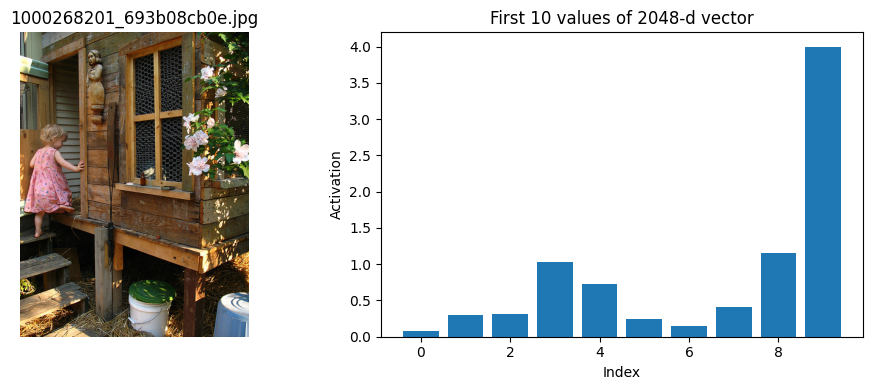

Vector dtype: float32, min: 0.000, max: 9.227


In [9]:
sample_name = unique_images[0]
sample_path = os.path.join(IMAGES_DIR, sample_name)
img = Image.open(sample_path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.imshow(img)
ax1.set_title(f"{sample_name}")
ax1.axis("off")

feat = features[sample_name]
ax2.bar(range(10), feat[:10])
ax2.set_title("First 10 values of 2048-d vector")
ax2.set_xlabel("Index")
ax2.set_ylabel("Activation")

plt.tight_layout()
plt.show()

print(f"Vector dtype: {feat.dtype}, min: {feat.min():.3f}, max: {feat.max():.3f}")

## Ekspor

Dictionary fitur disimpan ke `model/features.pkl` menggunakan `pickle`. File ini akan dimuat oleh notebook 04 (training LSTM) dan 05 (training GRU) sebagai masukan untuk *encoder*.

## Ekspor

Dictionary fitur disimpan ke `model/features.pkl` menggunakan `pickle`. File ini akan dimuat oleh notebook 04 (training LSTM) dan 05 (training GRU) sebagai masukan untuk *encoder*.

In [10]:
# Simpan dictionary fitur ke file
out_path = os.path.join(MODEL_DIR, "features.pkl")
with open(out_path, "wb") as f:
    pickle.dump(features, f)
print(f"Features saved to {out_path}")

Features saved to ../model/features.pkl


## Kesimpulan dan Tahap Selanjutnya

Notebook ini berhasil mengekstrak vektor fitur 2048-d untuk seluruh gambar dalam dataset menggunakan ResNet50 pre-trained. Representasi visual ini akan digunakan sebagai masukan untuk model *decoder*.

**Tahap selanjutnya:** **[04_train_lstm.ipynb](04_train_lstm.ipynb)** — Pelatihan model CNN+LSTM dengan *teacher forcing*.